# ECMM422J Coursework 1: ECG Heartbeat Classification with a 1D CNN

**Author:**  Arush Kumar Vishwakarma
**Student ID:** 750096984

## Overview
1D Convolutional Neural Network to classify ECG heartbeats into five categories: Normal, Supraventricular, Ventricular, Fusion, and Unknown/Paced.

The pipeline runs in 11 stages:
1. Setup & reproducibility
2. Load data
3. Preprocessing
4. Visualisation
5. Model architecture
6. Class weight calculation
7. K-fold cross-validation + hyperparameter search
8. Architecture Comparison and Ablation Study
9. Final Model Selection and Training
10. Model Evaluation
11. Advanced Evaluation Visualisations

---
## Stage 1: Setup and Reproducibility

Import libraries and lock random seeds so the experiment produces identical results every time.

In [1]:
# Stage 1: Setup and Reproducibility

import os
import random
import json
import time

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.utils import to_categorical, plot_model

from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score
)

# Reproducibility: lock random seeds
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Plot styling
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

# Confirm environment
print('TensorFlow version:', tf.__version__)
print('Devices available:', tf.config.list_physical_devices())
print('Seed locked to:', SEED)

TensorFlow version: 2.10.0
Devices available: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Seed locked to: 42


---
## Stage 2: Load the Data

The training and test sets are provided as separate CSV files. Each row is one heartbeat:
the first 187 columns are time-domain ECG samples (already normalised to ~[0,1] by the
dataset authors), and the last column is the integer class label in {0, 1, 2, 3, 4}.

No header row, so we pass `header=None` to pandas.

In [ ]:
# Stage 2: Load the training and test data

TRAIN_PATH = 'data/mitbih_train.csv'
TEST_PATH = 'data/mitbih_test.csv'

# Read both CSVs. header=None because the files have no column names.
t0 = time.time()
train_df = pd.read_csv(TRAIN_PATH, header=None)
test_df = pd.read_csv(TEST_PATH,  header=None)
print(f'Loaded both CSVs in {time.time() - t0:.1f}s')

# Split each DataFrame into features (X) and label (y).
X_train = train_df.iloc[:, :-1].values.astype(np.float32)
y_train = train_df.iloc[:, -1].values.astype(np.int64)

X_test = test_df.iloc[:, :-1].values.astype(np.float32)
y_test = test_df.iloc[:, -1].values.astype(np.int64)

print(f'\nShapes:')
print(f'  X_train: {X_train.shape}   y_train: {y_train.shape}')
print(f'  X_test : {X_test.shape}   y_test : {y_test.shape}')

print(f'\nLabel values present (train): {np.unique(y_train)}')
print(f'Label values present (test) : {np.unique(y_test)}')

print(f'\nFeature value range:')
print(f'  Train: [{X_train.min():.3f}, {X_train.max():.3f}]')
print(f'  Test : [{X_test.min():.3f}, {X_test.max():.3f}]')

Loaded both CSVs in 14.0s

Shapes:
  X_train: (87554, 187)   y_train: (87554,)
  X_test : (21892, 187)   y_test : (21892,)

Label values present (train): [0 1 2 3 4]
Label values present (test) : [0 1 2 3 4]

Feature value range:
  Train: [0.000, 1.000]
  Test : [0.000, 1.000]


---
## Stage 3: Preprocessing

### 3a. Missing values (per class)

The first step is to check the data set to see
Whether or not any values are missing. If there are no missing values (which turns out to be the case), no
imputation is needed

In [ ]:
# Stage 3a: Check for missing values per class

# Count NaNs in each set
n_missing_train = int(np.isnan(X_train).sum())
n_missing_test = int(np.isnan(X_test).sum())
print(f'Missing values in X_train: {n_missing_train}')
print(f'Missing values in X_test : {n_missing_test}')

Missing values in X_train: 0
Missing values in X_test : 0


### 3b. Normalisation check

The dataset authors pre-normalised each beat by dividing by its
peak amplitude, so values are already in [0, 1].

In [ ]:
# Stage 3b: Confirm features are in [0, 1]

print('Training set:')
print(f'  min = {X_train.min():.4f}')
print(f'  max = {X_train.max():.4f}')
print(f'  mean = {X_train.mean():.4f}')
print(f'  std = {X_train.std():.4f}')

print('\nTest set:')
print(f'  min  = {X_test.min():.4f}')
print(f'  max  = {X_test.max():.4f}')
print(f'  mean = {X_test.mean():.4f}')
print(f'  std  = {X_test.std():.4f}')

print('\nNo further scaling applied.')

Training set:
  min  = 0.0000
  max  = 1.0000
  mean = 0.1743
  std  = 0.2263

Test set:
  min  = 0.0000
  max  = 1.0000
  mean = 0.1735
  std  = 0.2256

No further scaling applied.


### 3c. Reshape for Conv1D and one-hot encode labels

Conv1D expects input shape `(batch, timesteps, channels)`, so we reshape from `(N, 187)`
to `(N, 187, 1)`. The trailing `1` is the channel dimension (ECG has a single channel).

For labels, we one-hot encode: class 2 → `[0, 0, 1, 0, 0]`. This pairs with the softmax
output and categorical cross-entropy loss, and tells the model the classes are categorical
rather than ordered.

In [ ]:
# Stage 3c: Reshape inputs for Conv1D and one-hot encode labels

NUM_CLASSES = 5
TIMESTEPS = X_train.shape[1]  

# Reshape (N, 187) to (N, 187, 1)
X_train = X_train.reshape(-1, TIMESTEPS, 1)
X_test  = X_test.reshape(-1, TIMESTEPS, 1)


# One-hot encode labels
y_train_oh = to_categorical(y_train, NUM_CLASSES)
y_test_oh  = to_categorical(y_test, NUM_CLASSES)



print(f'TIMESTEPS = {TIMESTEPS}')
print(f'NUM_CLASSES = {NUM_CLASSES}')

print()
print(f'X_train reshaped to: {X_train.shape}')
print(f'X_test  reshaped to: {X_test.shape}')
print()
print(f'y_train one-hot: {y_train_oh.shape}')
print(f'y_test  one-hot: {y_test_oh.shape}')
print()
print(f'Example label conversion:')
print(f'  Integer label: {y_train[0]}')
print(f'  One-hot label: {y_train_oh[0]}')

TIMESTEPS = 187
NUM_CLASSES = 5

X_train reshaped to: (87554, 187, 1)
X_test  reshaped to: (21892, 187, 1)

y_train one-hot: (87554, 5)
y_test  one-hot: (21892, 5)

Example label conversion:
  Integer label: 0
  One-hot label: [1. 0. 0. 0. 0.]


---
## Stage 4: Visualisation

### 4a. Class distribution

The dataset is extremely skewed. Visualising the per Class Counts makes the severity
The overall accuracy measure is an incomplete measure, because the majority are from the normal class.
While the minority classes are misclassified, and normal class can achieve high accuracy.

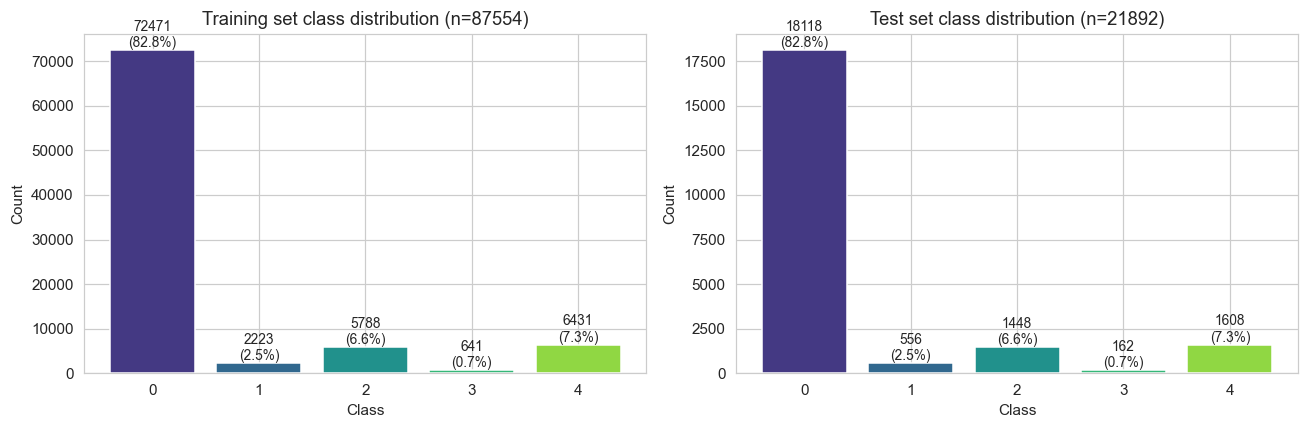

In [6]:
# Stage 4a: Class distribution bar charts

class_names = ['Normal', 'Hypersensitive', 'Type 1', 'Type 2', 'Type 3']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y, name in zip(axes, [y_train, y_test], ['Training', 'Test']):
    counts = pd.Series(y).value_counts().sort_index()
    ax.bar(counts.index, counts.values, color=sns.color_palette('viridis', 5))
    ax.set_title(f'{name} set class distribution (n={len(y)})')
    ax.set_xlabel('Class')
    ax.set_ylabel('Count')
    # annotate each bar with its count and percentage
    for i, v in enumerate(counts.values):
        ax.text(counts.index[i], v, f'{v}\n({100*v/len(y):.1f}%)',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('fig_class_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

### 4b. Representative heartbeat per class

Plotting one beat from each class shows the morphological differences the model must learn:
peak position, secondary deflections, signal duration. These local-in-time patterns are
exactly what 1D convolutions are designed to detect, the justification for choosing a CNN.

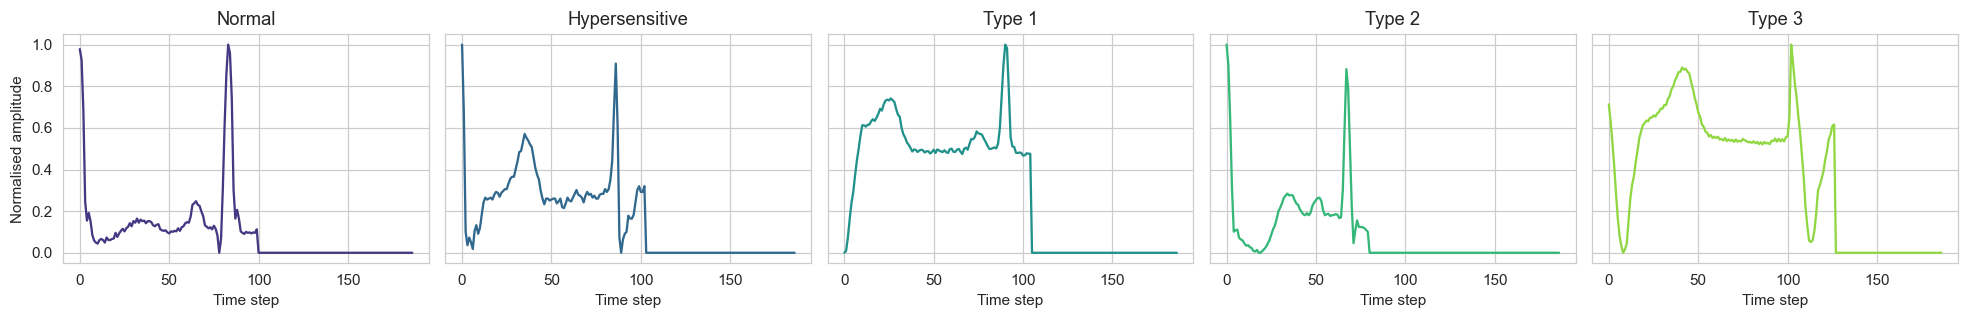

In [7]:
# Stage 4b: Plot one representative beat from each class

fig, axes = plt.subplots(1, 5, figsize=(18, 3), sharey=True)

for c in range(5):

    # find the first sample belonging to class c
    idx = np.where(y_train == c)[0][0]

    axes[c].plot(X_train[idx].squeeze(), color=sns.color_palette('viridis', 5)[c])
    axes[c].set_title(class_names[c])
    axes[c].set_xlabel('Time step')


axes[0].set_ylabel('Normalised amplitude')
plt.tight_layout()
plt.savefig('fig_sample_beats.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Stage 5: Model Architecture (1D CNN)

We use a 1D Convolutional Neural Network. ECG beats are time series whose discriminative
features (QRS complex shape, secondary deflections, durations) are local in time, exactly
what 1D convolutions capture. This inductive bias makes a CNN more suitable than an MLP
(which ignores temporal order) or an LSTM (slower, with no clear accuracy benefit here for
fixed-length beats).

**Design:** three convolutional blocks (Conv1D → BatchNorm → ReLU → MaxPool → Dropout) with
increasing filter counts (32 → 64 → 128), followed by Global Average Pooling, a dense layer,
and a softmax output. The builder is parameterised so the same code supports the
hyperparameter search in Stage 7.

In [8]:
# Stage 5: Define the 1D CNN architecture

def build_cnn(input_len=187, num_classes=5,
              filters=(32, 64, 128), kernel_size=5,
              dropout=0.3, dense_units=64, learning_rate=1e-3):
    """
    Build and compile a 1D CNN for ECG beat classification.

    Parameters:
      input_len     : length of the input signal
      num_classes   : number of output classes
      filters       : tuple of filter counts, one per conv block
      kernel_size   : width of each convolutional filter
      dropout       : dropout rate applied after each block and the dense layer
      dense_units   : size of the penultimate dense layer
      learning_rate : Adam optimiser step size
    """
    inputs = layers.Input(shape=(input_len, 1))
    x = inputs

    # Convolutional blocks
    for f in filters:
        x = layers.Conv1D(f, kernel_size=kernel_size, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.MaxPooling1D(pool_size=2)(x)
        x = layers.Dropout(dropout)(x)

    # Collapse the time dimension by averaging
    x = layers.GlobalAveragePooling1D()(x)

    # Dense head
    x = layers.Dense(dense_units, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    # Assemble and compile
    model = models.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',   # pairs with one-hot labels + softmax
        metrics=['accuracy'],
    )
    return model

# Build one instance with default hyperparameters
demo_model = build_cnn()
demo_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 187, 1)]          0         
                                                                 
 conv1d (Conv1D)             (None, 187, 32)           192       
                                                                 
 batch_normalization (BatchN  (None, 187, 32)          128       
 ormalization)                                                   
                                                                 
 activation (Activation)     (None, 187, 32)           0         
                                                                 
 max_pooling1d (MaxPooling1D  (None, 93, 32)           0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 93, 32)            0     

### 5b. Architecture diagram

**A detailed Architecture diagram is present in the report.**

In [9]:
demo_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 187, 1)]          0         
                                                                 
 conv1d (Conv1D)             (None, 187, 32)           192       
                                                                 
 batch_normalization (BatchN  (None, 187, 32)          128       
 ormalization)                                                   
                                                                 
 activation (Activation)     (None, 187, 32)           0         
                                                                 
 max_pooling1d (MaxPooling1D  (None, 93, 32)           0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 93, 32)            0     

---
## Stage 6: Class Weights for Imbalance (Computed for the Ablation)

Given the severe imbalance between the largest (Normal) and smallest (Type 2) classes, an
unweighted model could in principle minimise loss by predicting Normal almost everywhere.
A standard remedy is to weight the loss inversely with class frequency so errors on rare
classes are penalised more heavily.

We apply **square-root tempering** to the standard inverse-frequency weights, because the raw
weights are so aggressive they destabilise early training; the square root preserves the
relative ordering while compressing the dynamic range.

These weights are used as one factor in the **ablation study in Stage 8**, which compares
training with and without class weighting. As the ablation will show, on this dataset the
minority classes are large enough in absolute terms that class weighting is unnecessary and
actually degrades performance, so the **final model trains without them**.

In [10]:
# Stage 6: Compute square-root-tempered class weights

# Standard "balanced" inverse-frequency weights from sklearn
raw_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=y_train
)

# Square-root tempering
class_weights = {i: float(np.sqrt(w)) for i, w in enumerate(raw_weights)}

print('Class | Count  | Raw weight | Tempered weight')
print('-' * 50)
counts = np.bincount(y_train, minlength=NUM_CLASSES)
for i in range(NUM_CLASSES):
    print(f'  {i}   | {counts[i]:6d} |   {raw_weights[i]:6.2f}   |     {class_weights[i]:5.2f}')

print('\nclass_weights dict passed to training:')
print(class_weights)

Class | Count  | Raw weight | Tempered weight
--------------------------------------------------
  0   |  72471 |     0.24   |      0.49
  1   |   2223 |     7.88   |      2.81
  2   |   5788 |     3.03   |      1.74
  3   |    641 |    27.32   |      5.23
  4   |   6431 |     2.72   |      1.65

class_weights dict passed to training:
{0: 0.49155358388725223, 1: 2.806617717813582, 2: 1.7393570132743923, 3: 5.226656743811354, 4: 1.650113202508115}


---
## Stage 7: K-Fold Cross-Validation + Hyperparameter Search

We tune hyperparameters using **random search** (more efficient than grid search per
Bergstra & Bengio, 2012), evaluating each configuration with **stratified 5-fold
cross-validation**. Stratification preserves class proportions in every fold, which is
essential under severe imbalance. The configuration with the highest mean validation
accuracy across folds is selected as the working hyperparameter set used by the ablation
in Stage 8 and the final training in Stage 9.

In [ ]:
# Stage 7a: Define the hyperparameter search space

search_space = {
    'learning_rate': [1e-3, 5e-4, 1e-4],  # Adam step size
    'dropout': [0.2, 0.3, 0.4],  # regularisation strength
    'kernel_size': [3, 5, 7],  # width of conv filters
    'batch_size': [64, 128, 256],  # samples per gradient update
}


N_CONFIGS = 12      # number of random configurations to try
N_FOLDS = 5      # k in k-fold cross-validation
CV_EPOCHS = 12     # epochs per fold during the search

# Sample N_CONFIGS random configurations
rng = np.random.default_rng(SEED)
def sample_config():
    return {k: rng.choice(v).item() for k, v in search_space.items()}

configs = [sample_config() for _ in range(N_CONFIGS)]
print(f'Search budget: {N_CONFIGS} configs x {N_FOLDS} folds x up to {CV_EPOCHS} epochs')
print(f'\nConfigurations to evaluate:')
for i, c in enumerate(configs):
    print(f'  Config {i}: {c}')

Search budget: 12 configs x 5 folds x up to 12 epochs

Configurations to evaluate:
  Config 0: {'learning_rate': 0.001, 'dropout': 0.4, 'kernel_size': 5, 'batch_size': 128}
  Config 1: {'learning_rate': 0.0005, 'dropout': 0.4, 'kernel_size': 3, 'batch_size': 256}
  Config 2: {'learning_rate': 0.001, 'dropout': 0.2, 'kernel_size': 5, 'batch_size': 256}
  Config 3: {'learning_rate': 0.0001, 'dropout': 0.4, 'kernel_size': 7, 'batch_size': 256}
  Config 4: {'learning_rate': 0.0005, 'dropout': 0.2, 'kernel_size': 7, 'batch_size': 128}
  Config 5: {'learning_rate': 0.0005, 'dropout': 0.3, 'kernel_size': 3, 'batch_size': 256}
  Config 6: {'learning_rate': 0.0001, 'dropout': 0.3, 'kernel_size': 5, 'batch_size': 256}
  Config 7: {'learning_rate': 0.0005, 'dropout': 0.3, 'kernel_size': 5, 'batch_size': 64}
  Config 8: {'learning_rate': 0.001, 'dropout': 0.3, 'kernel_size': 7, 'batch_size': 64}
  Config 9: {'learning_rate': 0.0001, 'dropout': 0.4, 'kernel_size': 3, 'batch_size': 128}
  Config 10:

In [12]:
# Stage 7b: Cross-validation routine for one configuration

def run_cv(config, X, y_int, y_oh, n_folds=5, epochs=12,
           class_weights=None, verbose=0):
    """
    Evaluate one hyperparameter config using stratified k-fold CV.
    Returns: mean val accuracy, std of val accuracy, list of per-fold histories.
    """
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=SEED)
    fold_accuracies = []
    fold_histories  = []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y_int)):
        tf.keras.backend.clear_session()   # free memory between folds

        model = build_cnn(
            input_len=X.shape[1],
            num_classes=NUM_CLASSES,
            kernel_size=int(config['kernel_size']),
            dropout=float(config['dropout']),
            learning_rate=float(config['learning_rate']),
        )

        # stop early if validation loss stops improving
        es = callbacks.EarlyStopping(monitor='val_loss', patience=3,
                                     restore_best_weights=True)

        history = model.fit(
            X[tr_idx], y_oh[tr_idx],
            validation_data=(X[va_idx], y_oh[va_idx]),
            epochs=epochs,
            batch_size=int(config['batch_size']),
            class_weight=class_weights,
            callbacks=[es],
            verbose=verbose,
        )

        best_val_acc = max(history.history['val_accuracy'])
        fold_accuracies.append(best_val_acc)
        fold_histories.append(history.history)
        print(f'    Fold {fold+1}/{n_folds}: val_acc = {best_val_acc:.4f}')

    return float(np.mean(fold_accuracies)), float(np.std(fold_accuracies)), fold_histories

In [13]:
# Stage 7c: Run the random search

results = []
search_start = time.time()

for i, cfg in enumerate(configs):
    print(f'\n=== Config {i+1}/{len(configs)}: {cfg} ===')
    cfg_start = time.time()
    mean_acc, std_acc, histories = run_cv(
        cfg, X_train, y_train, y_train_oh,
        n_folds=N_FOLDS, epochs=CV_EPOCHS, class_weights=class_weights
    )
    results.append({
        'config': cfg,
        'mean_val_acc': mean_acc,
        'std_val_acc': std_acc,
        'histories': histories,
    })
    print(f'  >>> mean val_acc = {mean_acc:.4f} +/- {std_acc:.4f}  '
          f'({time.time()-cfg_start:.0f}s)')

print(f'\nTotal search time: {time.time()-search_start:.0f}s')

# Build a results table sorted best-first
summary = pd.DataFrame([
    {**r['config'], 'mean_val_acc': r['mean_val_acc'], 'std_val_acc': r['std_val_acc']}
    for r in results
]).sort_values('mean_val_acc', ascending=False).reset_index(drop=True)

summary.to_csv('cv_results.csv', index=False)   # save for the report
print('\n=== Hyperparameter search results (best first) ===')
print(summary.to_string(index=False))


=== Config 1/12: {'learning_rate': 0.001, 'dropout': 0.4, 'kernel_size': 5, 'batch_size': 128} ===
    Fold 1/5: val_acc = 0.9309
    Fold 2/5: val_acc = 0.9504
    Fold 3/5: val_acc = 0.9432
    Fold 4/5: val_acc = 0.9505
    Fold 5/5: val_acc = 0.9467
  >>> mean val_acc = 0.9443 +/- 0.0072  (115s)

=== Config 2/12: {'learning_rate': 0.0005, 'dropout': 0.4, 'kernel_size': 3, 'batch_size': 256} ===
    Fold 1/5: val_acc = 0.9143
    Fold 2/5: val_acc = 0.8842
    Fold 3/5: val_acc = 0.9307
    Fold 4/5: val_acc = 0.8705
    Fold 5/5: val_acc = 0.8962
  >>> mean val_acc = 0.8992 +/- 0.0213  (54s)

=== Config 3/12: {'learning_rate': 0.001, 'dropout': 0.2, 'kernel_size': 5, 'batch_size': 256} ===
    Fold 1/5: val_acc = 0.9605
    Fold 2/5: val_acc = 0.9608
    Fold 3/5: val_acc = 0.9553
    Fold 4/5: val_acc = 0.9491
    Fold 5/5: val_acc = 0.9601
  >>> mean val_acc = 0.9572 +/- 0.0045  (63s)

=== Config 4/12: {'learning_rate': 0.0001, 'dropout': 0.4, 'kernel_size': 7, 'batch_size': 256

Best configuration: {'learning_rate': 0.001, 'dropout': 0.3, 'kernel_size': 7, 'batch_size': 64}
Best mean CV accuracy: 0.9683 +/- 0.0025


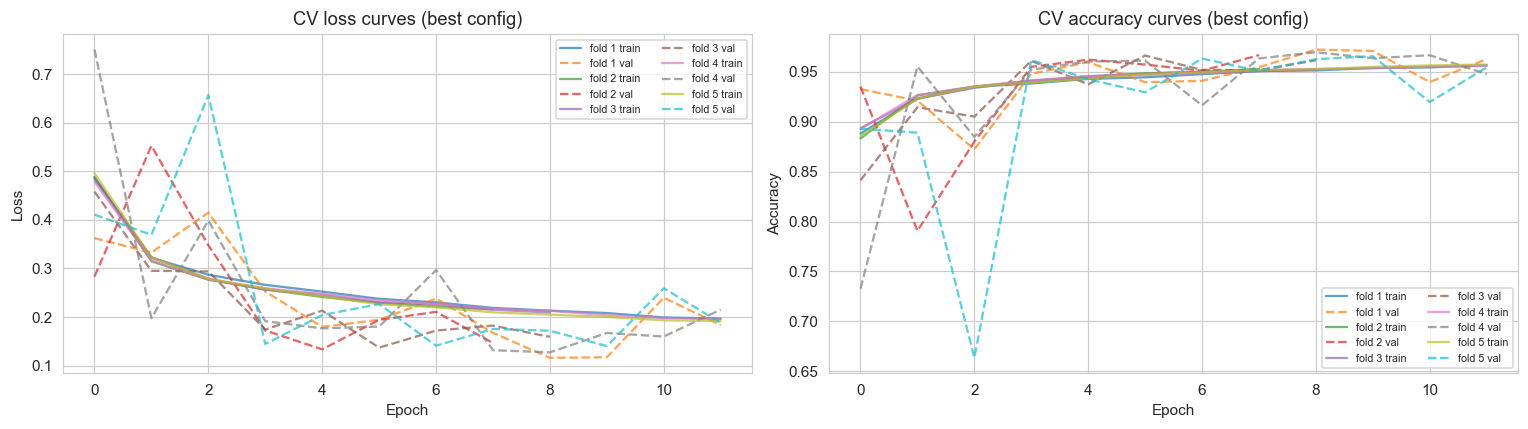

In [14]:
# Stage 7d: Select best config and plot its cross-validation learning curves

best_idx = int(np.argmax([r['mean_val_acc'] for r in results]))
best_config = results[best_idx]['config']
best_histories = results[best_idx]['histories']

print('Best configuration:', best_config)
print(f"Best mean CV accuracy: {results[best_idx]['mean_val_acc']:.4f} "
      f"+/- {results[best_idx]['std_val_acc']:.4f}")

# Plot loss and accuracy curves across the 5 folds for the best config
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for fold, h in enumerate(best_histories):
    axes[0].plot(h['loss'],     alpha=0.7, label=f'fold {fold+1} train')
    axes[0].plot(h['val_loss'], alpha=0.7, linestyle='--', label=f'fold {fold+1} val')
    axes[1].plot(h['accuracy'],     alpha=0.7, label=f'fold {fold+1} train')
    axes[1].plot(h['val_accuracy'], alpha=0.7, linestyle='--', label=f'fold {fold+1} val')

axes[0].set_title('CV loss curves (best config)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(fontsize=7, ncol=2)
axes[1].set_title('CV accuracy curves (best config)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig('fig_cv_curves.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Stage 8: Architecture Comparison and Ablation Study

To justify our design choices empirically rather than by assertion, we conduct a controlled
2x2 study varying two factors: architecture (plain CNN vs residual CNN with skip connections)
and class-weighting (enabled vs disabled). All four variants use the best hyperparameters from
Stage 7 and are evaluated identically on the held-out test set. The best-performing
configuration is then adopted as the final model.

In [15]:
# Stage 8a: Build a residual-CNN variant

def build_resnet_cnn(input_len=187, num_classes=5, kernel_size=7,
                     dropout=0.3, learning_rate=1e-3):
    """
    1D CNN with residual connections.
    Each residual block: Conv-BN-ReLU-Conv-BN, then add the input, then ReLU.
    """
    def res_block(x, filters):
        shortcut = x
        # main path
        y = layers.Conv1D(filters, kernel_size, padding='same')(x)
        y = layers.BatchNormalization()(y)
        y = layers.Activation('relu')(y)
        y = layers.Conv1D(filters, kernel_size, padding='same')(y)
        y = layers.BatchNormalization()(y)
        # project the shortcut if channel counts differ
        if shortcut.shape[-1] != filters:
            shortcut = layers.Conv1D(filters, 1, padding='same')(shortcut)
            shortcut = layers.BatchNormalization()(shortcut)
        # add and activate
        y = layers.Add()([y, shortcut])
        y = layers.Activation('relu')(y)
        y = layers.MaxPooling1D(2)(y)
        y = layers.Dropout(dropout)(y)
        return y

    inputs = layers.Input(shape=(input_len, 1))
    x = inputs
    for f in (32, 64, 128):
        x = res_block(x, f)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    model.compile(optimizer=optimizers.Adam(learning_rate=learning_rate),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

resnet_demo = build_resnet_cnn()
print(f'Residual CNN parameters: {resnet_demo.count_params():,}')
print(f'Baseline CNN parameters: {build_cnn(kernel_size=7).count_params():,}')

Residual CNN parameters: 244,645
Baseline CNN parameters: 81,605


In [16]:
# Stage 8b: Helper to train a model variant and return its test metrics

def train_and_eval(model_builder, use_class_weights, label, epochs=30):
    
    """Train a fresh model with the best hyperparameters and evaluate on the test set."""
    tf.keras.backend.clear_session()
    model = model_builder(
        input_len=TIMESTEPS, num_classes=NUM_CLASSES,
        kernel_size=int(best_config['kernel_size']),
        dropout=float(best_config['dropout']),
        learning_rate=float(best_config['learning_rate']),
    )
    # stratified shuffled split
    from sklearn.model_selection import train_test_split
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train_oh, test_size=0.1, stratify=y_train,
        random_state=SEED, shuffle=True
    )
    es = callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
    rlrop = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

    cw = class_weights if use_class_weights else None
    t0 = time.time()
    model.fit(X_tr, y_tr, validation_data=(X_val, y_val),
              epochs=epochs, batch_size=int(best_config['batch_size']),
              class_weight=cw, callbacks=[es, rlrop], verbose=0)

    # evaluate on test
    y_pred = model.predict(X_test, batch_size=256, verbose=0).argmax(axis=1)
    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    per_class_f1 = f1_score(y_test, y_pred, average=None, zero_division=0)
    print(f'{label}: test acc {acc:.4f}, macro-F1 {macro_f1:.4f} ({time.time()-t0:.0f}s)')
    return {'label': label, 'acc': acc, 'macro_f1': macro_f1,
            'per_class_f1': per_class_f1, 'params': model.count_params()}

In [17]:
# Stage 8c: Run the comparison (3 models, ~5-10 min total on your GPU)

experiments = []

# 1. Baseline CNN with class weights
experiments.append(train_and_eval(build_cnn, use_class_weights=True,
                                   label='Plain CNN + class weights'))

# 2. Baseline CNN WITHOUT class weights
experiments.append(train_and_eval(build_cnn, use_class_weights=False,
                                   label='Plain CNN, NO class weights'))

# 3. Residual CNN with class weights
experiments.append(train_and_eval(build_resnet_cnn, use_class_weights=True,
                                   label='Residual CNN + class weights'))

comp = pd.DataFrame([
    {'Model': e['label'], 'Params': e['params'],
     'Test Acc': e['acc'], 'Macro-F1': e['macro_f1'],
     'F1 Normal': e['per_class_f1'][0], 'F1 Supravent.': e['per_class_f1'][1],
     'F1 Ventric.': e['per_class_f1'][2], 'F1 Fusion': e['per_class_f1'][3],
     'F1 Paced': e['per_class_f1'][4]}
    for e in experiments
])
comp.to_csv('comparison_results.csv', index=False)
print('\n=== Model comparison ===')
print(comp.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

Plain CNN + class weights: test acc 0.9719, macro-F1 0.8678 (94s)
Plain CNN, NO class weights: test acc 0.9814, macro-F1 0.8927 (141s)
Residual CNN + class weights: test acc 0.9815, macro-F1 0.9023 (293s)

=== Model comparison ===
                       Model  Params  Test Acc  Macro-F1  F1 Normal  F1 Supravent.  F1 Ventric.  F1 Fusion  F1 Paced
   Plain CNN + class weights   81605    0.9719    0.8678     0.9844         0.6743       0.9301     0.7668    0.9834
 Plain CNN, NO class weights   81605    0.9814    0.8927     0.9905         0.7500       0.9537     0.7806    0.9885
Residual CNN + class weights  244645    0.9815    0.9023     0.9904         0.8168       0.9599     0.7545    0.9898


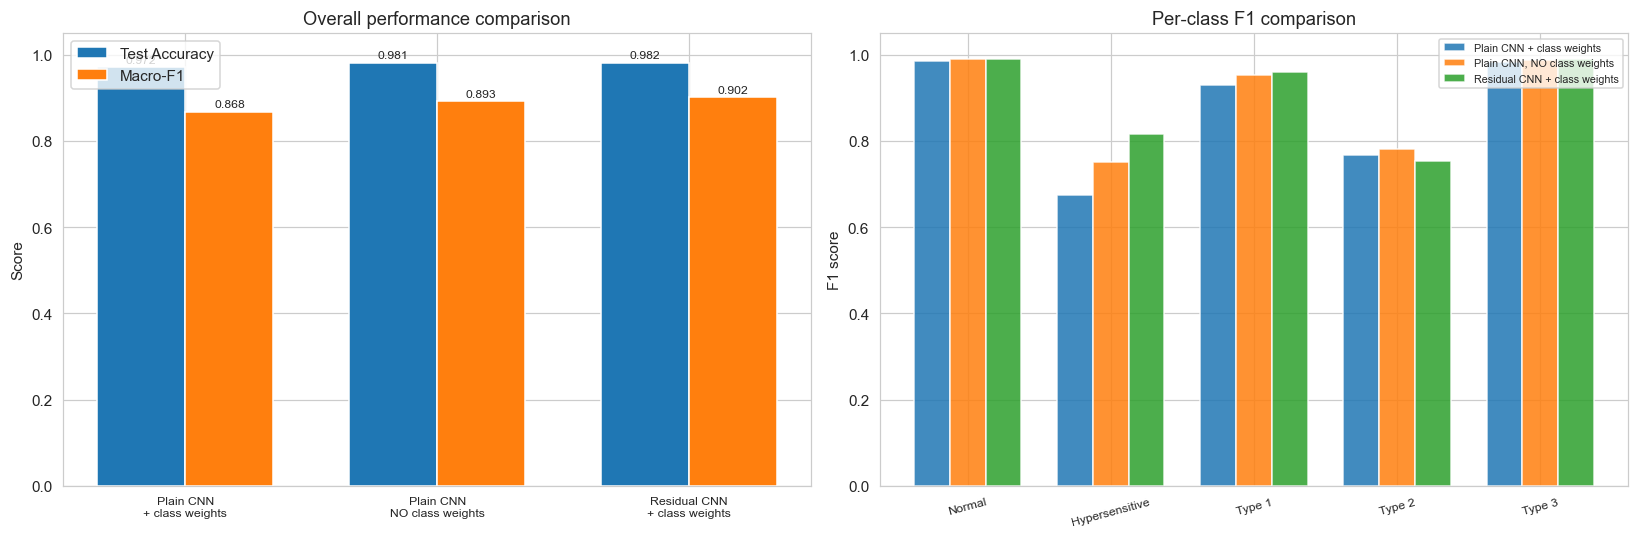

In [18]:
# Stage 8d: Visualise the comparison

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: overall accuracy and macro-F1
labels = [e['label'].replace(' + ', '\n+ ').replace(', ', '\n') for e in experiments]
x = np.arange(len(experiments)); w = 0.35
axes[0].bar(x - w/2, [e['acc'] for e in experiments], w, label='Test Accuracy')
axes[0].bar(x + w/2, [e['macro_f1'] for e in experiments], w, label='Macro-F1')
axes[0].set_xticks(x); axes[0].set_xticklabels(labels, fontsize=8)
axes[0].set_ylabel('Score'); axes[0].set_title('Overall performance comparison')
axes[0].legend(); axes[0].set_ylim(0, 1.05)
for i, e in enumerate(experiments):
    axes[0].text(i - w/2, e['acc']+0.01, f"{e['acc']:.3f}", ha='center', fontsize=8)
    axes[0].text(i + w/2, e['macro_f1']+0.01, f"{e['macro_f1']:.3f}", ha='center', fontsize=8)

# Right: per-class F1 shows where class weights matter most
cw = 0.25
for i, e in enumerate(experiments):
    axes[1].bar(np.arange(5) + (i-1)*cw, e['per_class_f1'], cw, label=e['label'], alpha=0.85)
axes[1].set_xticks(np.arange(5)); axes[1].set_xticklabels(class_names, rotation=15, fontsize=8)
axes[1].set_ylabel('F1 score'); axes[1].set_title('Per-class F1 comparison')
axes[1].legend(fontsize=7); axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('fig_model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

In [19]:
# Stage 8e: 2x2 grid - Residual CNN WITHOUT class weights
experiments.append(train_and_eval(build_resnet_cnn, use_class_weights=False,
                                   label='Residual CNN, NO class weights'))

# Rebuild the full comparison table
comp = pd.DataFrame([
    {'Model': e['label'], 'Params': e['params'],
     'Test Acc': e['acc'], 'Macro-F1': e['macro_f1'],
     'F1 Normal': e['per_class_f1'][0], 'F1 Supravent.': e['per_class_f1'][1],
     'F1 Ventric.': e['per_class_f1'][2], 'F1 Fusion': e['per_class_f1'][3],
     'F1 Paced': e['per_class_f1'][4]}
    for e in experiments
])
comp.to_csv('comparison_results.csv', index=False)
print('\n=== Full 2x2 comparison (architecture x class-weighting) ===')
print(comp.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

Residual CNN, NO class weights: test acc 0.9895, macro-F1 0.9373 (287s)

=== Full 2x2 comparison (architecture x class-weighting) ===
                         Model  Params  Test Acc  Macro-F1  F1 Normal  F1 Supravent.  F1 Ventric.  F1 Fusion  F1 Paced
     Plain CNN + class weights   81605    0.9719    0.8678     0.9844         0.6743       0.9301     0.7668    0.9834
   Plain CNN, NO class weights   81605    0.9814    0.8927     0.9905         0.7500       0.9537     0.7806    0.9885
  Residual CNN + class weights  244645    0.9815    0.9023     0.9904         0.8168       0.9599     0.7545    0.9898
Residual CNN, NO class weights  244645    0.9895    0.9373     0.9949         0.8748       0.9722     0.8489    0.9956


---
## Stage 9: Final Model Selection and Training

The ablation above shows the **Residual CNN without class weighting** performs best. We adopt
this configuration as the final model, retrain it on the full training set, and save it as
the deliverable . The learning curves below and the evaluation in Stages 10
and 11 all correspond to this final model.

In [20]:
# Stage 8f: Adopt the Residual CNN with no class weights as the FINAL model
from sklearn.model_selection import train_test_split

print('Retraining the best variant (Residual CNN, no class weights) as the final model...')

# Stratified shuffled 90/10 split
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train_oh, test_size=0.1,
    stratify=y_train, random_state=SEED, shuffle=True
)

tf.keras.backend.clear_session()
final_model = build_resnet_cnn(
    input_len=TIMESTEPS, num_classes=NUM_CLASSES,
    kernel_size=int(best_config['kernel_size']),
    dropout=float(best_config['dropout']),
    learning_rate=float(best_config['learning_rate']),
)
final_model.summary()

es = callbacks.EarlyStopping(monitor='val_loss', patience=6,
                             restore_best_weights=True, verbose=1)
rlrop = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=3, min_lr=1e-6, verbose=1)

history = final_model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=int(best_config['batch_size']),
    callbacks=[es, rlrop],
    verbose=1,
)
print(f'\nTrained for {len(history.history["loss"])} epochs')

final_model.save('ANN-model.keras')
print('Saved Residual CNN as ANN-model.keras')

Retraining the best variant (Residual CNN, no class weights) as the final model...
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 187, 1)]     0           []                               
                                                                                                  
 conv1d (Conv1D)                (None, 187, 32)      256         ['input_1[0][0]']                
                                                                                                  
 batch_normalization (BatchNorm  (None, 187, 32)     128         ['conv1d[0][0]']                 
 alization)                                                                                       
                                                                                                  
 activation

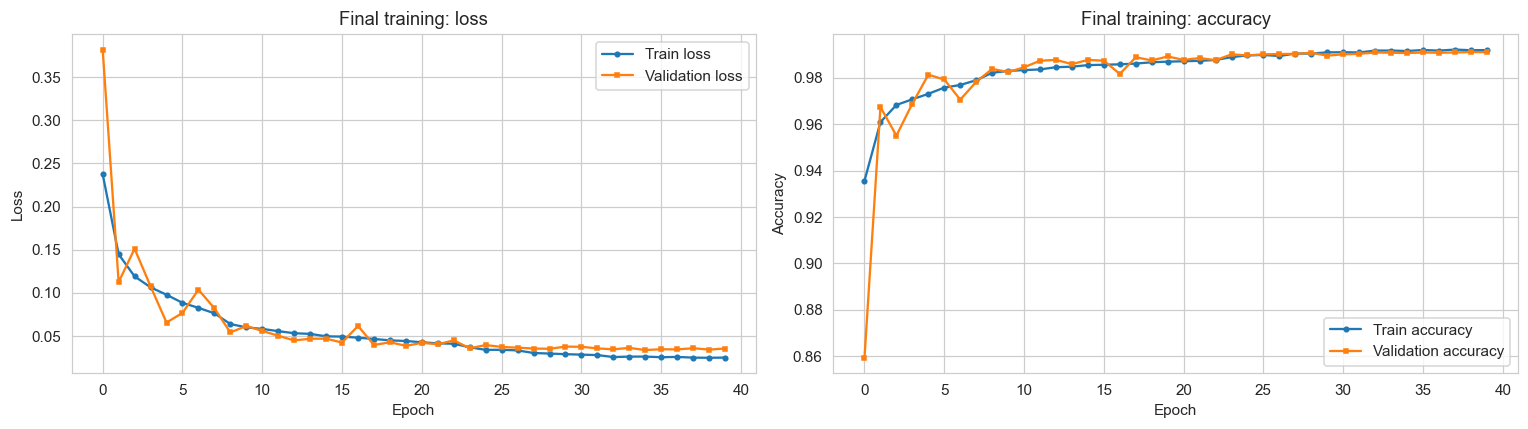

Saved fig_final_curves.png and final_history.json


In [21]:
# Stage 9a: Plot final training learning curves

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss
axes[0].plot(history.history['loss'], label='Train loss', marker='o', markersize=3)
axes[0].plot(history.history['val_loss'], label='Validation loss', marker='s', markersize=3)
axes[0].set_title('Final training: loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train accuracy', marker='o', markersize=3)
axes[1].plot(history.history['val_accuracy'], label='Validation accuracy', marker='s', markersize=3)
axes[1].set_title('Final training: accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend()

plt.tight_layout()
plt.savefig('fig_final_curves.png', bbox_inches='tight', dpi=150)
plt.show()

with open('final_history.json', 'w') as f:
    json.dump({k: [float(v) for v in vs] for k, vs in history.history.items()}, f, indent=2)
print('Saved fig_final_curves.png and final_history.json')

---
## Stage 10: Model Evaluation

We evaluate the final model on both the training and test sets, reporting overall accuracy and
per-class precision, recall (sensitivity), specificity and F1, together with confusion matrices.
Per-class metrics are essential under class imbalance, where overall accuracy is dominated by
the majority class.

In [22]:
# Stage 10a: Evaluation helper functions

def per_class_specificity(cm):
    """
    Specificity for each class in a multi-class confusion matrix.
    For class c: treat all other classes as 'negative'.
      Specificity_c = TN / (TN + FP)
    """
    spec = []
    total = cm.sum()
    for c in range(cm.shape[0]):
        TP = cm[c, c]
        FN = cm[c, :].sum() - TP
        FP = cm[:, c].sum() - TP
        TN = total - TP - FN - FP
        spec.append(TN / (TN + FP) if (TN + FP) > 0 else 0.0)
    return np.array(spec)

def evaluate(model, X, y_int, set_name):
    """Compute and print all required metrics for one dataset."""
    probs  = model.predict(X, batch_size=256, verbose=0)
    y_pred = probs.argmax(axis=1)

    acc  = accuracy_score(y_int, y_pred)
    prec = precision_score(y_int, y_pred, average=None, zero_division=0)
    rec  = recall_score(y_int, y_pred, average=None, zero_division=0)   
    f1   = f1_score(y_int, y_pred, average=None, zero_division=0)
    cm   = confusion_matrix(y_int, y_pred)
    spec = per_class_specificity(cm)

    print(f'\n{"="*55}')
    print(f'  {set_name} SET - overall accuracy: {acc:.4f}')
    print(f'{"="*55}')
    df = pd.DataFrame({
        'class':              class_names,
        'precision':          prec,
        'recall/sensitivity': rec,
        'specificity':        spec,
        'f1':                 f1,
    })
    print(df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
    print(f'\n  Macro avg - precision {prec.mean():.4f}, '
          f'recall {rec.mean():.4f}, specificity {spec.mean():.4f}, F1 {f1.mean():.4f}')

    return {'acc': acc, 'precision': prec, 'recall': rec,
            'specificity': spec, 'f1': f1, 'cm': cm, 'y_pred': y_pred}

# Evaluate on BOTH sets
train_results = evaluate(final_model, X_train, y_train, 'TRAIN')
test_results  = evaluate(final_model, X_test,  y_test,  'TEST')


  TRAIN SET - overall accuracy: 0.9953
         class  precision  recall/sensitivity  specificity     f1
        Normal     0.9974              0.9979       0.9874 0.9976
Hypersensitive     0.9681              0.9429       0.9992 0.9553
        Type 1     0.9881              0.9917       0.9992 0.9899
        Type 2     0.8943              0.8846       0.9992 0.8894
        Type 3     0.9975              0.9986       0.9998 0.9981

  Macro avg - precision 0.9691, recall 0.9631, specificity 0.9970, F1 0.9661

  TEST SET - overall accuracy: 0.9895
         class  precision  recall/sensitivity  specificity     f1
        Normal     0.9933              0.9967       0.9679 0.9950
Hypersensitive     0.9297              0.8327       0.9984 0.8786
        Type 1     0.9697              0.9710       0.9978 0.9703
        Type 2     0.8701              0.8272       0.9991 0.8481
        Type 3     0.9944              0.9956       0.9996 0.9950

  Macro avg - precision 0.9515, recall 0.9247, spe

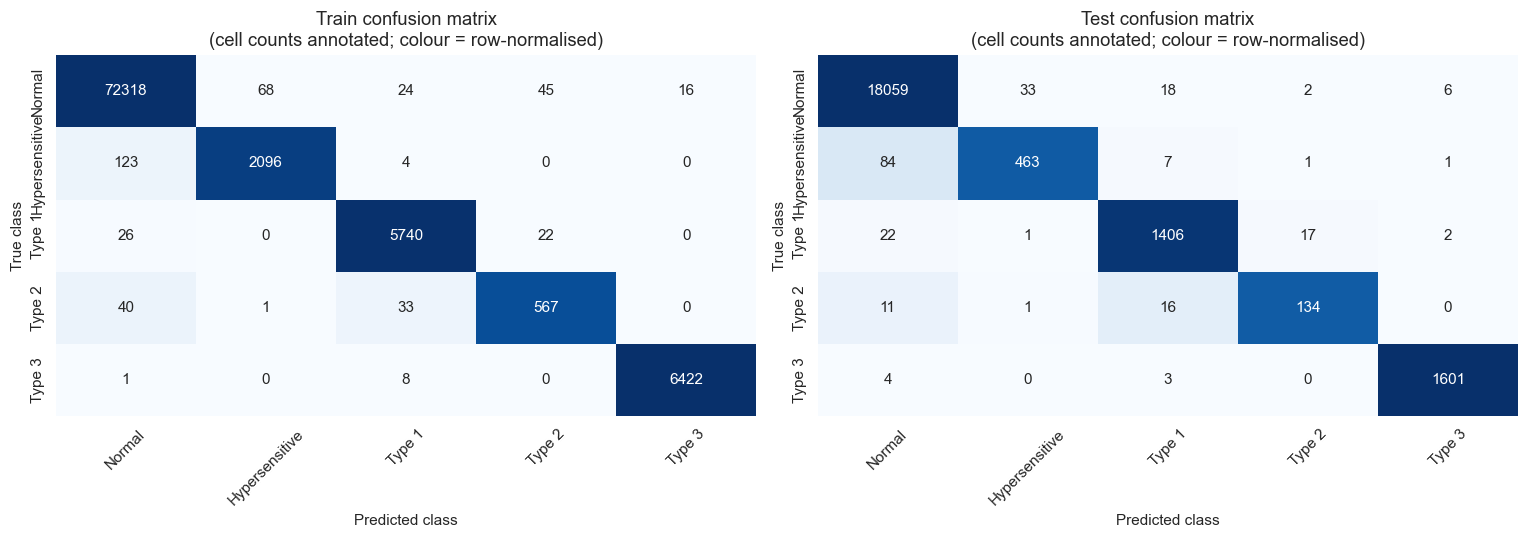

In [23]:
# Stage 10b: Side-by-side confusion matrices (train and test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, res, name in zip(axes, [train_results, test_results], ['Train', 'Test']):
    cm = res['cm']
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)   # row-normalise
    sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax, cbar=False)
    ax.set_title(f'{name} confusion matrix\n(cell counts annotated; colour = row-normalised)')
    ax.set_xlabel('Predicted class'); ax.set_ylabel('True class')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('fig_confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()

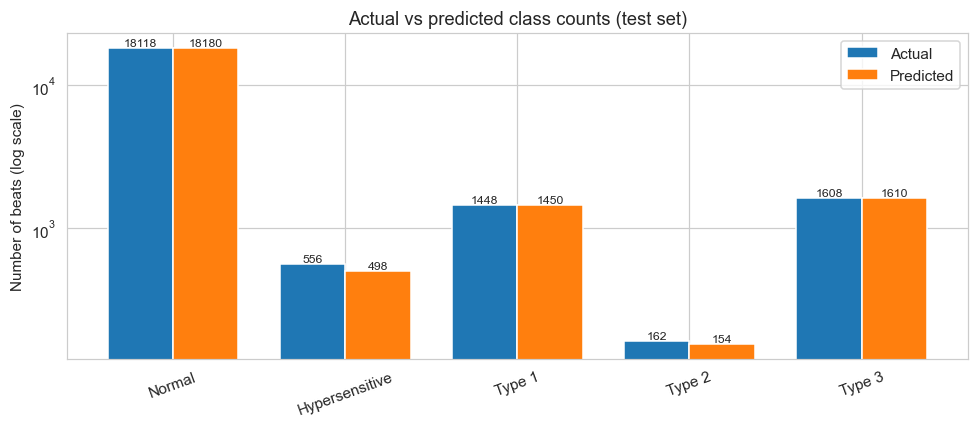

In [24]:
# Stage 10c: Actual vs predicted class counts
# A direct "actual vs predicted" visualisation: for each class, how many beats

actual_counts = np.bincount(y_test, minlength=NUM_CLASSES)
pred_counts   = np.bincount(test_results['y_pred'], minlength=NUM_CLASSES)

x = np.arange(NUM_CLASSES)
w = 0.38
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - w/2, actual_counts, w, label='Actual')
ax.bar(x + w/2, pred_counts,   w, label='Predicted')
ax.set_yscale('log')   # log scale because Normal dominates
ax.set_xticks(x); ax.set_xticklabels(class_names, rotation=20)
ax.set_ylabel('Number of beats (log scale)')
ax.set_title('Actual vs predicted class counts (test set)')
ax.legend()
for i in range(NUM_CLASSES):
    ax.text(i - w/2, actual_counts[i], str(actual_counts[i]), ha='center', va='bottom', fontsize=8)
    ax.text(i + w/2, pred_counts[i],   str(pred_counts[i]),   ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('fig_actual_vs_predicted.png', bbox_inches='tight', dpi=150)
plt.show()

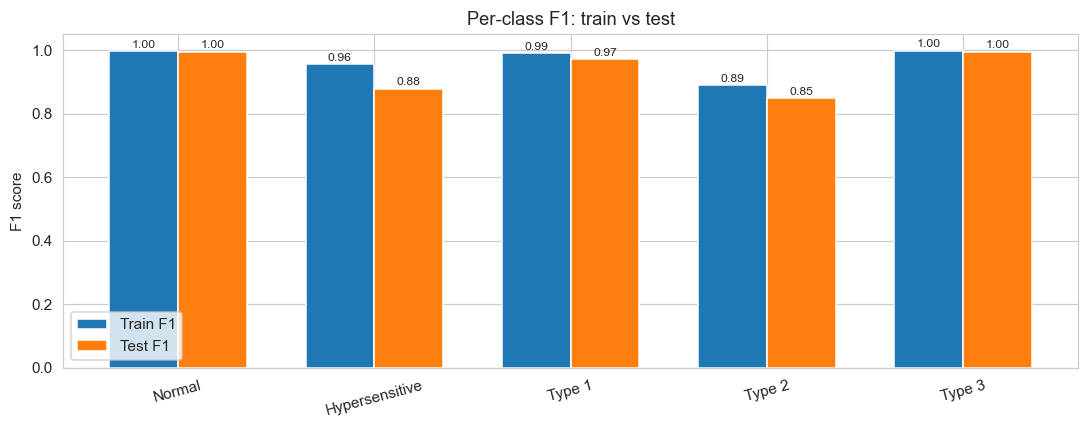

In [25]:
# Stage 10d: Per-class F1 comparison - visualises the generalisation gap

x = np.arange(NUM_CLASSES); w = 0.35
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - w/2, train_results['f1'], w, label='Train F1')
ax.bar(x + w/2, test_results['f1'],  w, label='Test F1')
ax.set_xticks(x); ax.set_xticklabels(class_names, rotation=15)
ax.set_ylabel('F1 score'); ax.set_title('Per-class F1: train vs test')
ax.legend(); ax.set_ylim(0, 1.05)
for i, (a, b) in enumerate(zip(train_results['f1'], test_results['f1'])):
    ax.text(i - w/2, a + 0.01, f'{a:.2f}', ha='center', fontsize=8)
    ax.text(i + w/2, b + 0.01, f'{b:.2f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('fig_f1_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

In [26]:
# Stage 10e: Quantify the bias-variance gap and save all metrics for the report

gap = train_results['acc'] - test_results['acc']
print(f'Train accuracy: {train_results["acc"]:.4f}')
print(f'Test  accuracy: {test_results["acc"]:.4f}')
print(f'Generalisation gap (train - test): {gap:.4f} ({gap*100:.2f} percentage points)')

results_to_save = {
    'best_config': best_config,
    'train': {
        'accuracy':    float(train_results['acc']),
        'precision':   train_results['precision'].tolist(),
        'recall':      train_results['recall'].tolist(),
        'specificity': train_results['specificity'].tolist(),
        'f1':          train_results['f1'].tolist(),
        'confusion_matrix': train_results['cm'].tolist(),
    },
    'test': {
        'accuracy':    float(test_results['acc']),
        'precision':   test_results['precision'].tolist(),
        'recall':      test_results['recall'].tolist(),
        'specificity': test_results['specificity'].tolist(),
        'f1':          test_results['f1'].tolist(),
        'confusion_matrix': test_results['cm'].tolist(),
    },
}
with open('final_metrics.json', 'w') as f:
    json.dump(results_to_save, f, indent=2)
print('\nSaved final_metrics.json (use these numbers in the report)')

Train accuracy: 0.9953
Test  accuracy: 0.9895
Generalisation gap (train - test): 0.0058 (0.58 percentage points)

Saved final_metrics.json (use these numbers in the report)


---
## Stage 11: Advanced Evaluation Visualisations

Beyond the confusion matrix, we examine per-class ROC curves (with AUC), precision-recall
curves, and a t-SNE projection of
the learned penultimate-layer features to visualise class separability.

In [27]:
# Stage 11a: Get predicted probabilities on the test set
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

# Predicted probabilities - softmax outputs, shape (n_samples, 5)
y_test_proba = final_model.predict(X_test, batch_size=256, verbose=0)

y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3, 4])

print('Probabilities shape:', y_test_proba.shape)
print('Binarised labels shape:', y_test_bin.shape)

Probabilities shape: (21892, 5)
Binarised labels shape: (21892, 5)


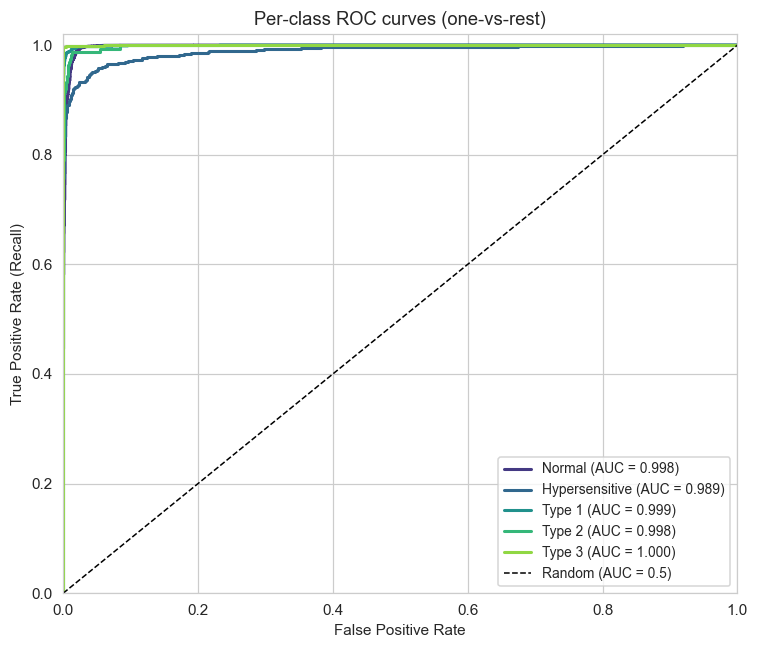

In [28]:
# Stage 11b: Per-class ROC curves with AUC

fig, ax = plt.subplots(figsize=(7, 6))
colors = sns.color_palette('viridis', 5)

for c in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_test_bin[:, c], y_test_proba[:, c])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colors[c], linewidth=2,
            label=f'{class_names[c]} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('Per-class ROC curves (one-vs-rest)')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.savefig('fig_roc_curves.png', bbox_inches='tight', dpi=150)
plt.show()

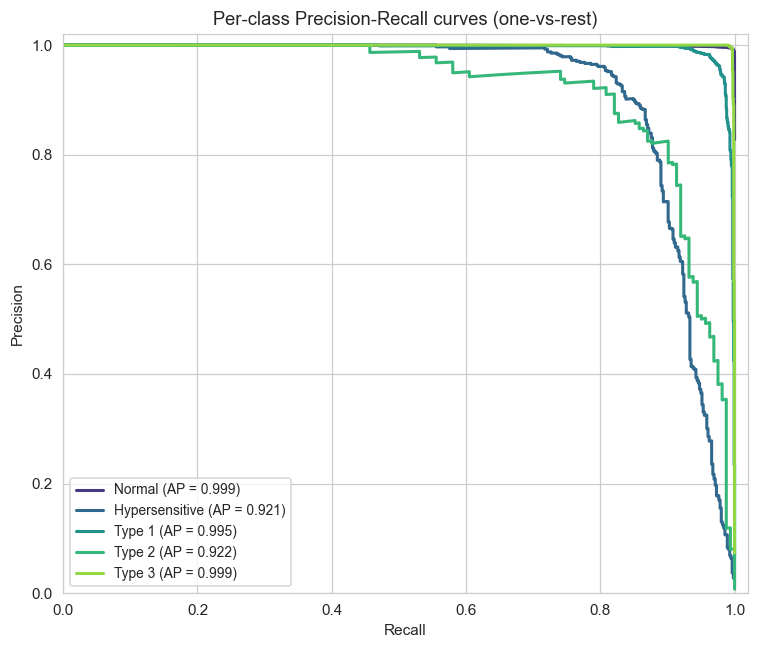

In [29]:
# Stage 11c: Per-class Precision-Recall curves with Average Precision

fig, ax = plt.subplots(figsize=(7, 6))

for c in range(NUM_CLASSES):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, c], y_test_proba[:, c])
    ap = average_precision_score(y_test_bin[:, c], y_test_proba[:, c])
    ax.plot(recall, precision, color=colors[c], linewidth=2,
            label=f'{class_names[c]} (AP = {ap:.3f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Per-class Precision-Recall curves (one-vs-rest)')
ax.legend(loc='lower left', fontsize=9)
ax.set_xlim(0, 1.02); ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.savefig('fig_pr_curves.png', bbox_inches='tight', dpi=150)
plt.show()

Using feature layer: dense
Extracted features shape: (3000, 64)
Running t-SNE (this may take a couple of minutes)...


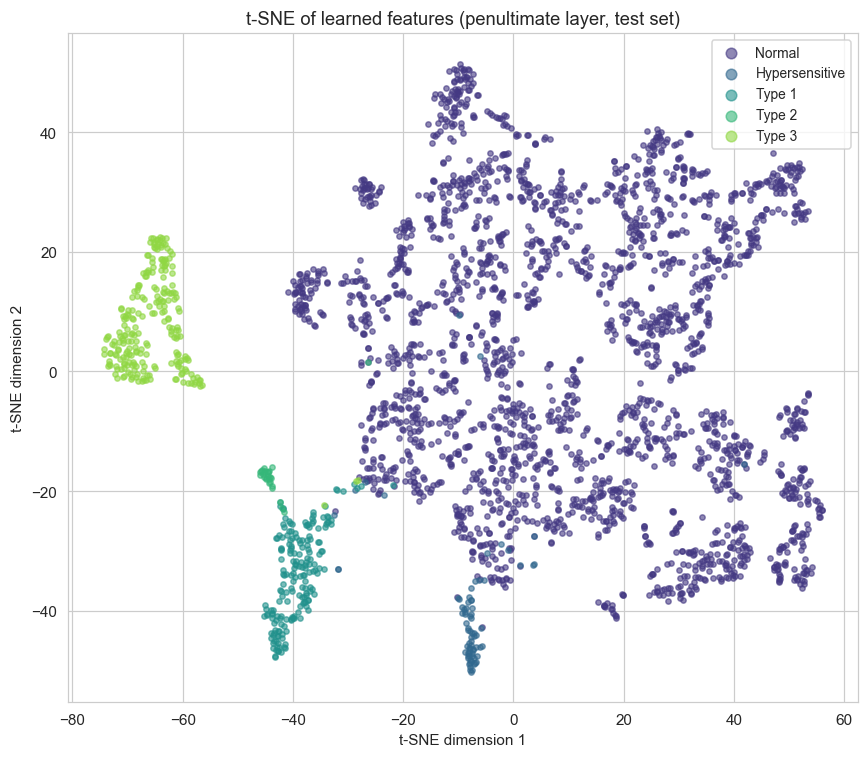

In [30]:
# Stage 11d: t-SNE projection of the penultimate-layer features
from sklearn.manifold import TSNE

# Build a feature extractor
feature_layer_name = None
for layer in final_model.layers:
    if 'dense' in layer.name and layer.output_shape[-1] == 64:
        feature_layer_name = layer.name
        break
print('Using feature layer:', feature_layer_name)

feature_extractor = models.Model(
    inputs=final_model.input,
    outputs=final_model.get_layer(feature_layer_name).output
)

# Extract features for a random subset of the test set
n_sample = 3000
rng_idx = np.random.default_rng(SEED)
sample_idx = rng_idx.choice(len(X_test), size=n_sample, replace=False)

features = feature_extractor.predict(X_test[sample_idx], batch_size=256, verbose=0)
print('Extracted features shape:', features.shape)


print('Running t-SNE (this may take a couple of minutes)...')
tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, init='pca')
features_2d = tsne.fit_transform(features)

# Plot
fig, ax = plt.subplots(figsize=(8, 7))
for c in range(NUM_CLASSES):
    mask = (y_test[sample_idx] == c)
    ax.scatter(features_2d[mask, 0], features_2d[mask, 1],
               color=colors[c], label=class_names[c], s=12, alpha=0.6)
ax.set_title('t-SNE of learned features (penultimate layer, test set)')
ax.set_xlabel('t-SNE dimension 1'); ax.set_ylabel('t-SNE dimension 2')
ax.legend(fontsize=9, markerscale=2)
plt.tight_layout()
plt.savefig('fig_tsne.png', bbox_inches='tight', dpi=150)
plt.show()

In [31]:
# Exact AUC and AP values
from sklearn.metrics import roc_auc_score, average_precision_score

print("Per-class ROC AUC and PR AP (residual final model):")
print(f"{'Class':<18} {'ROC AUC':>8} {'PR AP':>8}")
print("-" * 36)
for c in range(NUM_CLASSES):
    auc_c = roc_auc_score(y_test_bin[:, c], y_test_proba[:, c])
    ap_c  = average_precision_score(y_test_bin[:, c], y_test_proba[:, c])
    print(f"{class_names[c]:<18} {auc_c:>8.4f} {ap_c:>8.4f}")

Per-class ROC AUC and PR AP (residual final model):
Class               ROC AUC    PR AP
------------------------------------
Normal               0.9977   0.9994
Hypersensitive       0.9890   0.9213
Type 1               0.9994   0.9946
Type 2               0.9984   0.9224
Type 3               0.9999   0.9992
